## Problem 3: Adding polynomial features

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# load the auto-mpg dataset
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Theory/master/Data/auto.csv'
data = pd.read_csv(url)
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
389,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
390,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


The data concerns city-cycle fuel consumption in miles per gallon (mpg).

**Part 1:** Fit a model

$$
\mathrm{mpg} = \theta_0 + \theta_1\cdot \mathrm{weight}
$$

to the data.

In [7]:
X = np.ones((len(data),2))
X[:,1] = data['weight']

theta = np.linalg.lstsq(X,data['mpg'],rcond=None)[0]

Plot the data points and the fitted model

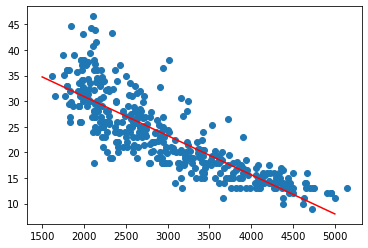

In [10]:
plt.scatter(data['weight'],data['mpg'])
x_plot = np.linspace(1500,5000,300)
y_plot = theta[0]+theta[1]*x_plot
plt.plot(x_plot,y_plot,color='red')

**Part 2:** Fit a model

$$
\mathrm{mpg} = \theta_0 + \theta_1\cdot \mathrm{weight} + \theta_2\cdot \mathrm{weight}^2
$$

to the data.

In [12]:
X = np.ones((len(data),3))
X[:,1] = data['weight']
X[:,2] = data['weight']**2

theta = np.linalg.lstsq(X,data['mpg'],rcond=None)[0]

Plot the data points and the fitted model

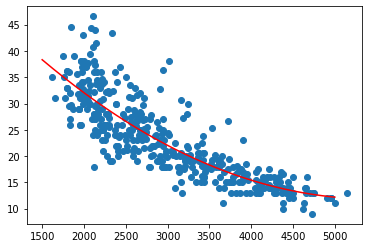

In [13]:
plt.scatter(data['weight'],data['mpg'])
x_plot = np.linspace(1500,5000,300)
y_plot = theta[0]+theta[1]*x_plot+theta[2]*x_plot**2
plt.plot(x_plot,y_plot,color='red')

**Part 3:** Fit a model

$$
\mathrm{mpg} = \theta_0 + \theta_1\cdot \mathrm{weight} + \theta_2 \cdot \mathrm{horsepower}
$$

to the data.

In [14]:
X = np.ones((len(data),3))
X[:,1] = data['weight']
X[:,2] = data['horsepower']

theta = np.linalg.lstsq(X,data['mpg'],rcond=None)[0]

Plot the data points and the fitted model

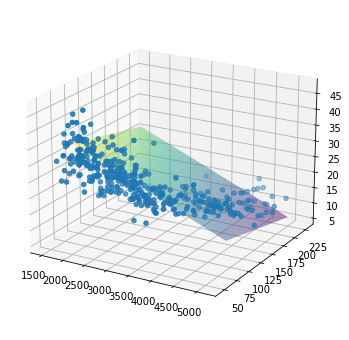

In [16]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')

ax.scatter(data['weight'],data['horsepower'],data['mpg'])

m_plot = 1000
x_plot = np.linspace(1500,5000,m_plot)
y_plot = np.linspace(90,225, m_plot)
X_plot,Y_plot = np.meshgrid(x_plot,y_plot)
Z_plot = theta[0] +theta[1]*X_plot +theta[2]*Y_plot
ax.plot_surface(X_plot,Y_plot,Z_plot,alpha=0.5,cmap = 'viridis')

ax.view_init(elev=20)

**Part 3:** Fit a model

$$
\mathrm{mpg} = \theta_0 + \theta_1\cdot \mathrm{weight} + \theta_2\cdot\mathrm{horsepower} + \theta_3\cdot\mathrm{weight}^2
+ \theta_4\cdot\mathrm{weight}\cdot\mathrm{horsepower} + \theta_5\cdot\mathrm{horsepower}^2
$$

to the data.

In [19]:
wt = data['weight']
hp = data['horsepower']
mpg = data['mpg']

X = np.ones((len(data),6))
X[:,1] = wt
X[:,2] = hp
X[:,3] = wt**2
X[:,4] = hp*wt
X[:,5] = hp**2

theta = np.linalg.lstsq(X,mpg,rcond=None)[0]

Plot the data points and the fitted model

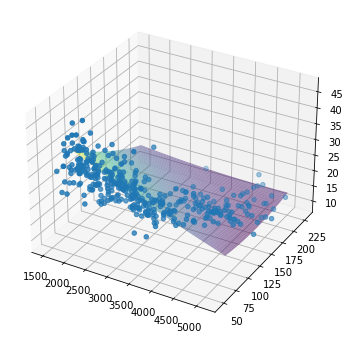

In [23]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')

ax.scatter(data['weight'],data['horsepower'],data['mpg'])

m_plot = 1000
x_plot = np.linspace(1500,5000,m_plot)
y_plot = np.linspace(90,225, m_plot)
X_plot,Y_plot = np.meshgrid(x_plot,y_plot)
Z_plot = theta[0] +theta[1]*X_plot +theta[2]*Y_plot+theta[3]*X_plot**2+theta[4]*X_plot*Y_plot+theta[5]*Y_plot**2
ax.plot_surface(X_plot,Y_plot,Z_plot,alpha=0.5,cmap = 'viridis')

ax.view_init(elev=30)

In [25]:
# I'll note that I don't love this plot- the fact that the mpg
# increases as we move down and to the left is underwhelming.